# はじめに

##
* 半年のコースの練習問題として
* なぜ岡山県に興味があったか
* 理由と今からやりたいこと


# 分析するデータ

* 用いたデータについて
* 利用規約について
* データの内容
* データの取得方法
* 岡山市の地理

# 実行環境

* パソコン
* 開発環境
* 言語
* ライブラリ

# 分析の過程

## 前処理について
## 予測について

## 中心市街地の分析


### `center_df` の前処理

In [117]:
!pip install matplotlib
!pip install matplotlib seaborn

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# center_df の前処理
center_df = pd.read_csv('area1_month.csv', encoding="cp932", header=1)
center_df.head()

,Unnamed: 0,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,2532.8,2611.6,880.7,768.9,904.5,797.8,826.2,966.3,...,NaN,祝休日,741.6,817.5,279.3,241.4,262.2,234.1,244.6,297.5
1,2018年2月,期間全体,2331.5,2388.7,829.0,688.6,828.4,738.4,749.8,886.0,...,NaN,祝休日,705.0,801.8,294.3,228.6,253.9,230.8,221.7,277.4
2,2018年3月,期間全体,2735.1,2754.3,953.2,810.7,956.0,848.9,878.7,1041.9,...,NaN,祝休日,832.1,923.6,322.4,272.4,301.2,264.5,262.2,332.9
3,2018年4月,期間全体,2599.5,2655.0,908.6,785.5,879.2,783.7,820.7,1076.8,...,NaN,祝休日,834.9,930.4,336.9,278.1,289.2,254.1,262.2,344.7
4,2018年5月,期間全体,2681.5,2722.5,988.5,812.1,895.5,814.2,821.8,1071.9,...,NaN,祝休日,846.1,951.5,372.0,273.0,286.6,259.4,259.4,347.2


In [119]:
pip install japanize-matplotlib

In [120]:
import japanize_matplotlib

In [121]:
center_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 30 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   88 non-null     object 
 1   Unnamed: 1   88 non-null     object 
 2   男性           88 non-null     float64
 3   女性           88 non-null     float64
 4   20代          88 non-null     float64
 5   30代          88 non-null     float64
 6   40代          88 non-null     float64
 7   50代          88 non-null     float64
 8   60代          88 non-null     float64
 9   70歳以上        88 non-null     float64
 10  Unnamed: 10  0 non-null      float64
 11  Unnamed: 11  88 non-null     object 
 12  男性.1         88 non-null     float64
 13  女性.1         88 non-null     float64
 14  20代.1        88 non-null     float64
 15  30代.1        88 non-null     float64
 16  40代.1        88 non-null     float64
 17  50代.1        88 non-null     float64
 18  60代.1        88 non-null     float64
 19  70歳以上.1   

In [122]:
center_df = center_df.rename(columns={'Unnamed: 0': 'ds'})
# .strアクセサーを使用する前に、'ds'が文字列型であることを確認
center_df['ds'] = center_df['ds'].astype(str).str.replace('年', '-').str.replace('月', '-01')
center_df['ds'] = pd.to_datetime(center_df['ds'])

# 不要な列を削除
columns_to_drop = ['Unnamed: 1', 'Unnamed: 10', 'Unnamed: 20', 'Unnamed: 21']

# columns_to_drop というリストに指定されている列のうち、center_df に実際に存在する列だけを選んで削除し、
#更新されたデータフレームを center_df に格納
center_df = center_df.drop(columns=[col for col in columns_to_drop if col in center_df.columns])

center_df.head()

,ds,男性,女性,20代,30代,40代,50代,60代,70歳以上,Unnamed: 11,...,60代.1,70歳以上.1,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018-01-01,2532.8,2611.6,880.7,768.9,904.5,797.8,826.2,966.3,平日,...,581.6,668.8,741.6,817.5,279.3,241.4,262.2,234.1,244.6,297.5
1,2018-02-01,2331.5,2388.7,829.0,688.6,828.4,738.4,749.8,886.0,平日,...,528.1,608.6,705.0,801.8,294.3,228.6,253.9,230.8,221.7,277.4
2,2018-03-01,2735.1,2754.3,953.2,810.7,956.0,848.9,878.7,1041.9,平日,...,616.5,708.9,832.1,923.6,322.4,272.4,301.2,264.5,262.2,332.9
3,2018-04-01,2599.5,2655.0,908.6,785.5,879.2,783.7,820.7,1076.8,平日,...,558.5,732.1,834.9,930.4,336.9,278.1,289.2,254.1,262.2,344.7
4,2018-05-01,2681.5,2722.5,988.5,812.1,895.5,814.2,821.8,1071.9,平日,...,562.4,724.6,846.1,951.5,372.0,273.0,286.6,259.4,259.4,347.2


### 中心市街地の滞在人口推移

#### `center_weekday_df` 平日の場合

In [123]:
# 中心市街地の平日滞在人口データを抽出するためのカラムリストを作成
demographic_columns = ['男性', '女性', '20代', '30代', '40代', '50代', '60代', '70歳以上']

# 平日用のDataFrameを作成
center_weekday_df = center_df[['ds'] + demographic_columns].copy()

#meltメソッドで縦持ちに変更
#ds以外は 'Category' とその値を含む 'Value' カラムにまとめ直し
center_weekday_melted = center_weekday_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')

#'DayType'カラムを追加して、すべてのロウにweekdayを格納
#pd.to_numeric() 関数で文字列を数値に変換
center_weekday_melted['DayType'] = 'weekday'
center_weekday_melted['Value'] = pd.to_numeric(center_weekday_melted['Value'])
center_weekday_melted.head()

,ds,Category,Value,DayType
0,2018-01-01,男性,2532.8,weekday
1,2018-02-01,男性,2331.5,weekday
2,2018-03-01,男性,2735.1,weekday
3,2018-04-01,男性,2599.5,weekday
4,2018-05-01,男性,2681.5,weekday


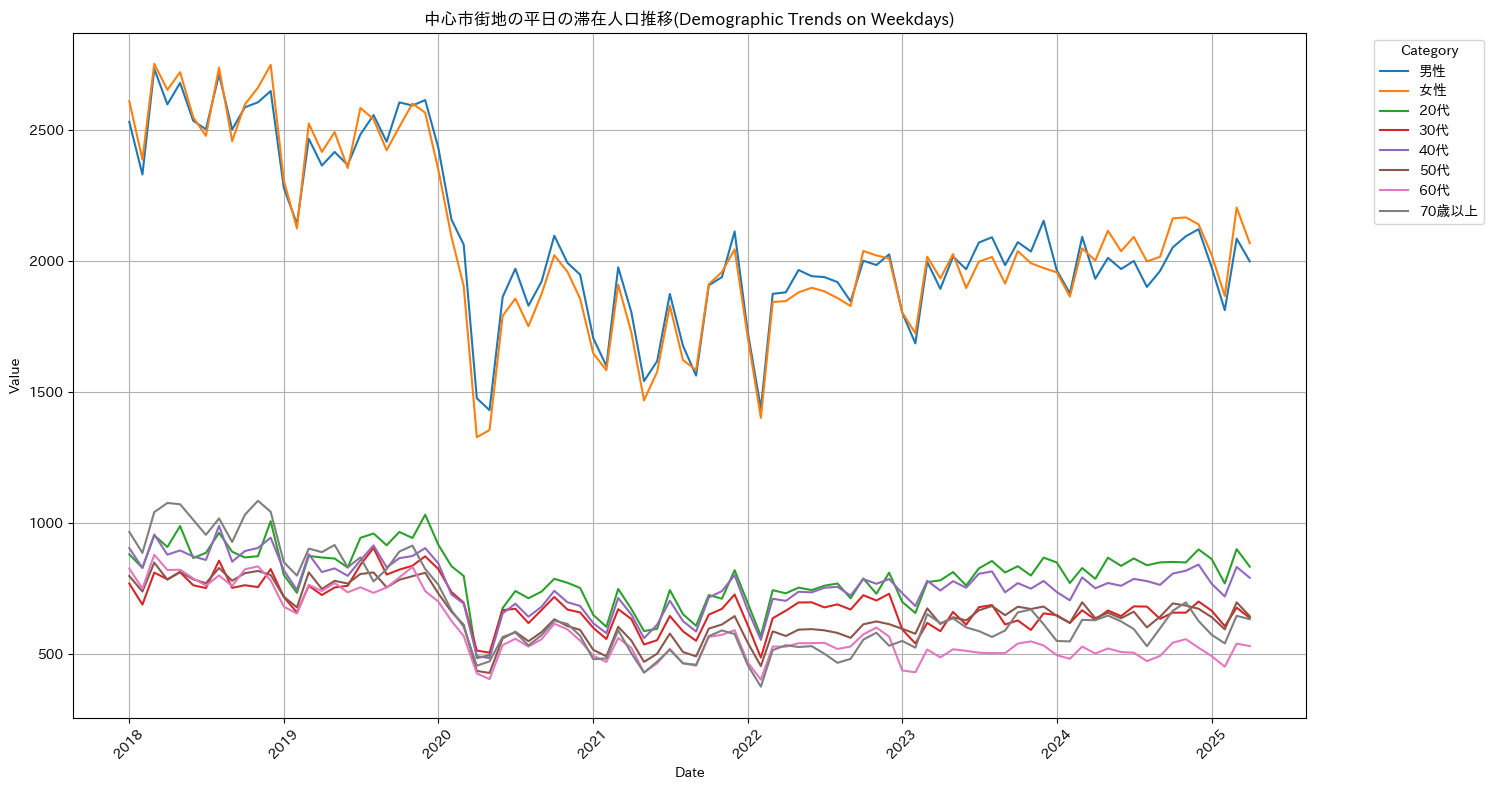

In [124]:

#グラフの描写
plt.figure(figsize=(15, 8))
sns.lineplot(data=center_weekday_melted, x='ds', y='Value', hue='Category')
plt.title('中心市街地の平日の滞在人口推移(Demographic Trends on Weekdays)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### `center_holiday_df` 休日の場合

In [125]:
from numpy._core.defchararray import center
# 中心市街地の休日滞在人口データを抽出するための列名リストを作成
# 既存のdemographic_columns（['男性', '女性', '20代', '30代', '40代', '50代', '60代', '70歳以上']）に.1のサフィックスを追加して、
# 新しいリストを作成（例: ['男性.1', '女性.1', ...]）。
center_holiday_demographic_columns = [col + '.1' for col in demographic_columns]
center_holiday_demographic_columns

['男性.1', '女性.1', '20代.1', '30代.1', '40代.1', '50代.1', '60代.1', '70歳以上.1']

In [126]:
# center_dfからからdsカラムと、center_holiday_demographic_columnsを抽出
# 新しいdfを作成
center_holiday_df = center_df[['ds'] + center_holiday_demographic_columns].copy()

#平日と同様に、縦持ち形式（melt）に変換
center_holiday_melted = center_holiday_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')
center_holiday_melted['DAyType'] = 'Holiday'

# center_holiday_meltedのCategoryカラムから.1サフィックスを削除して、表示名を元のカテゴリ名に戻します。
center_holiday_melted['Category'] = center_holiday_melted['Category'].str.replace('.1', '', regex=False)
center_holiday_melted['Value'] = pd.to_numeric(center_holiday_melted['Value'])
center_holiday_melted

,ds,Category,Value,DAyType
0,2018-01-01,男性,1791.2,Holiday
1,2018-02-01,男性,1626.6,Holiday
2,2018-03-01,男性,1903.0,Holiday
3,2018-04-01,男性,1764.6,Holiday
4,2018-05-01,男性,1835.4,Holiday
...,...,...,...,...
699,2024-12-01,70歳以上,458.1,Holiday
700,2025-01-01,70歳以上,403.8,Holiday
701,2025-02-01,70歳以上,361.6,Holiday
702,2025-03-01,70歳以上,437.7,Holiday


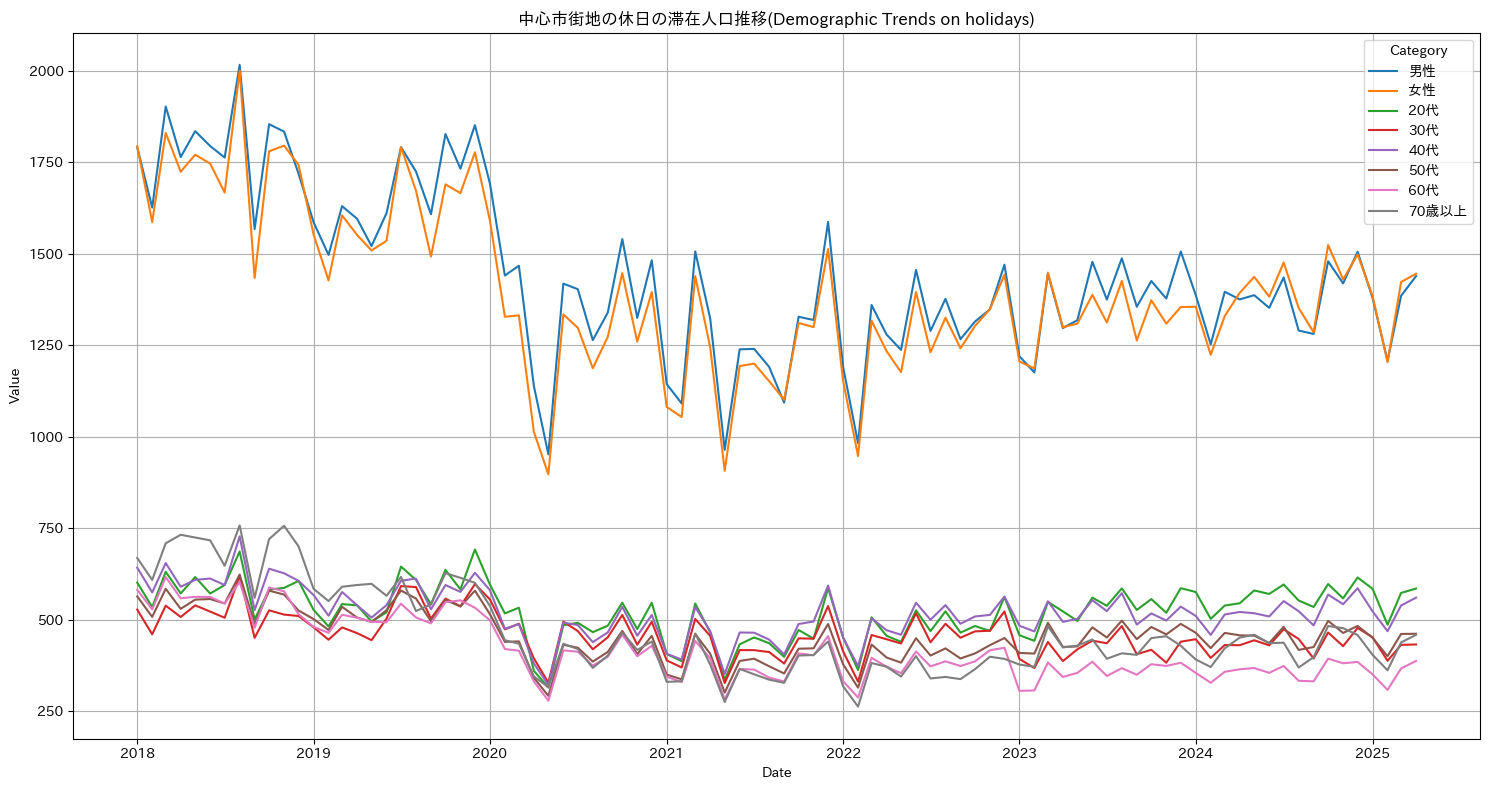

In [127]:
#中心市街地の休日滞在人口の推移を折れ線グラフでプロット
#center_holiday_meltedデータフレームを使用
plt.figure(figsize=(15, 8))
sns.lineplot(data=center_holiday_melted, x='ds', y='Value', hue='Category')
plt.title('中心市街地の休日の滞在人口推移(Demographic Trends on holidays)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.tight_layout()
plt.show()

### 予測結果①

### 中心市街地の季節性、トレンド

#### `center_weekday_df` 平日の場合

In [128]:
# Prophetに適用させるため、dsカラムとyに変換
# yは男性と女性を足した新しいカラムに変換
center_weekday_df['y'] = center_weekday_df['男性'] + center_weekday_df['女性']
center_weekday_df.head()

,ds,男性,女性,20代,30代,40代,50代,60代,70歳以上,y
0,2018-01-01,2532.8,2611.6,880.7,768.9,904.5,797.8,826.2,966.3,5144.4
1,2018-02-01,2331.5,2388.7,829.0,688.6,828.4,738.4,749.8,886.0,4720.2
2,2018-03-01,2735.1,2754.3,953.2,810.7,956.0,848.9,878.7,1041.9,5489.4
3,2018-04-01,2599.5,2655.0,908.6,785.5,879.2,783.7,820.7,1076.8,5254.5
4,2018-05-01,2681.5,2722.5,988.5,812.1,895.5,814.2,821.8,1071.9,5404.0


In [129]:

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    center_weekday_df['y'], # 'y'カラムに対して分解を実行
    model="additive",   # or "multiplicative"
    period=12            # 月次周期なら12
)

trend = result.trend
seasonal = result.seasonal
resid = result.resid

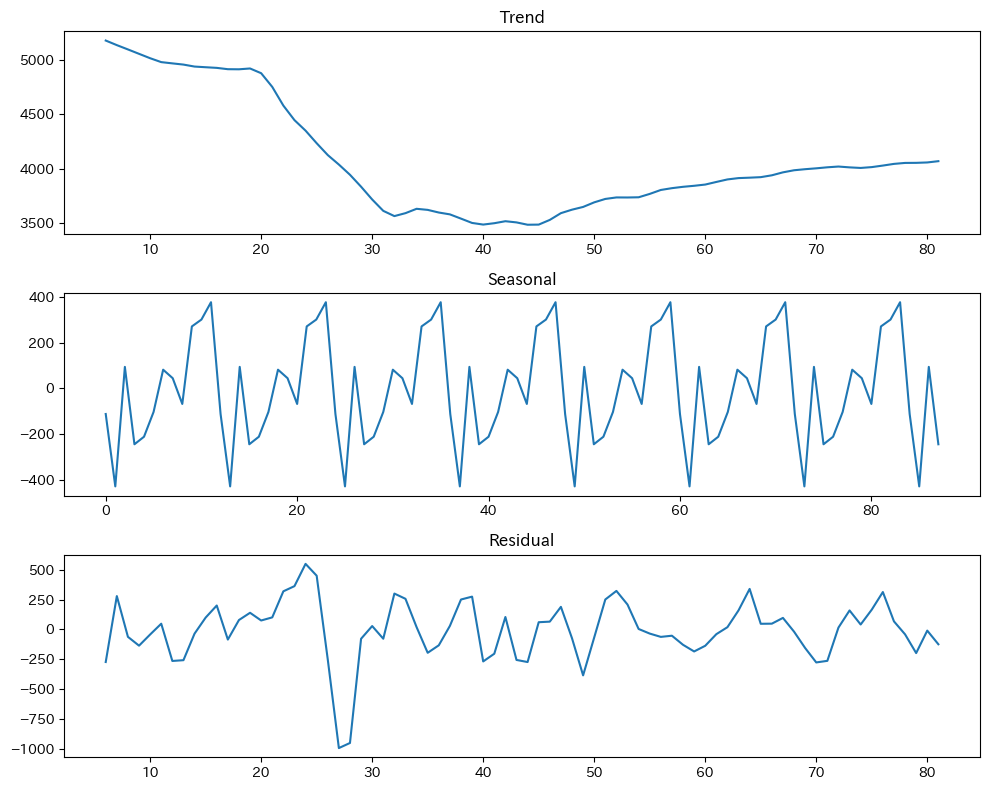

In [130]:

fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))

# トレンド成分のプロット
axes[0].plot(trend)
axes[0].set_title('Trend')

# 季節成分のプロット
axes[1].plot(seasonal)
axes[1].set_title('Seasonal')

# 残差成分のプロット
axes[2].plot(resid)
axes[2].set_title('Residual')

plt.tight_layout()
plt.show()

#### `center_holiday_df` 休日の場合

In [131]:
center_holiday_df.head()

,ds,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1
0,2018-01-01,1791.2,1794.1,601.4,527.6,642.2,563.7,581.6,668.8
1,2018-02-01,1626.6,1586.9,534.6,460.0,574.5,507.7,528.1,608.6
2,2018-03-01,1903.0,1830.7,630.8,538.3,654.8,584.4,616.5,708.9
3,2018-04-01,1764.6,1724.6,571.7,507.4,590.0,529.6,558.5,732.1
4,2018-05-01,1835.4,1771.0,616.5,539.1,608.9,554.8,562.4,724.6


In [132]:
# 平日と同様に、休日
# Prophetに適用させるため、dsカラムとyに変換
# yは男性と女性を足した新しいカラムに変換
center_holiday_df['y'] = center_holiday_df['男性.1'] + center_holiday_df['女性.1']
center_holiday_df.head()

,ds,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1,y
0,2018-01-01,1791.2,1794.1,601.4,527.6,642.2,563.7,581.6,668.8,3585.3
1,2018-02-01,1626.6,1586.9,534.6,460.0,574.5,507.7,528.1,608.6,3213.5
2,2018-03-01,1903.0,1830.7,630.8,538.3,654.8,584.4,616.5,708.9,3733.7
3,2018-04-01,1764.6,1724.6,571.7,507.4,590.0,529.6,558.5,732.1,3489.2
4,2018-05-01,1835.4,1771.0,616.5,539.1,608.9,554.8,562.4,724.6,3606.4


In [133]:

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    center_holiday_df['y'], # 'y'カラムに対して分解を実行
    model="additive",   # or "multiplicative"
    period=12            # 月次周期なら12
)

trend = result.trend
seasonal = result.seasonal
resid = result.resid

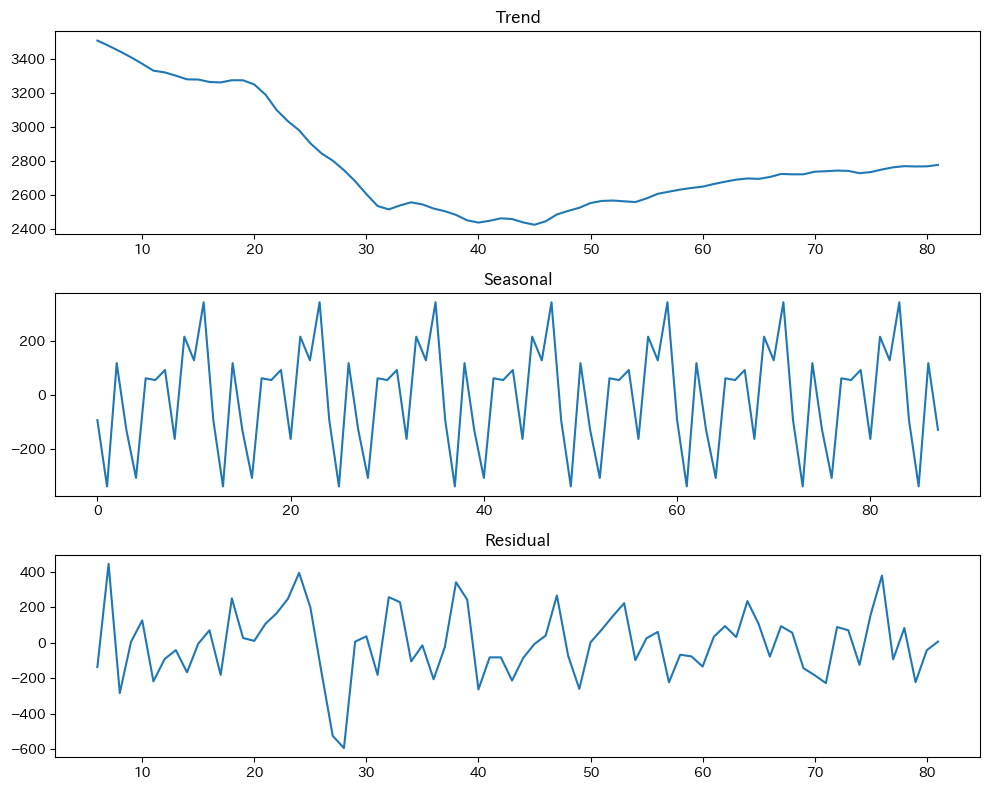

In [134]:

fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))

# トレンド成分のプロット
axes[0].plot(trend)
axes[0].set_title('Trend')

# 季節成分のプロット
axes[1].plot(seasonal)
axes[1].set_title('Seasonal')

# 残差成分のプロット
axes[2].plot(resid)
axes[2].set_title('Residual')

plt.tight_layout()
plt.show()

### 予測結果②

### 中心市街地のProphetモデル

In [135]:
#Prophetクラスをインポートし、インスタンス化
from prophet import Prophet
model = Prophet(seasonality_mode='multiplicative',interval_width=0.7)


#### `center_weekday_forecast` 平日の場合

In [136]:

model.fit(center_weekday_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [137]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
center_weekday_future = model.make_future_dataframe(periods=12, freq='MS')


In [138]:
#予測を実行
center_weekday_forecast = model.predict(center_weekday_future)

#出力された予測値や、不確実性区間を確認
center_weekday_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01,5309.489430,5031.152512,5607.387148
1,2018-02-01,4879.535917,4595.641689,5158.362141
2,2018-03-01,5494.366306,5214.746977,5799.343875
3,2018-04-01,5142.810875,4842.521528,5445.776799
4,2018-05-01,5188.523171,4917.397703,5469.371399
...,...,...,...,...
95,2025-12-01,4586.735822,4289.032298,4892.845356
96,2026-01-01,4080.882922,3796.240989,4372.509746
97,2026-02-01,3797.437081,3515.607110,4079.606212
98,2026-03-01,4324.616736,4021.781019,4608.462830


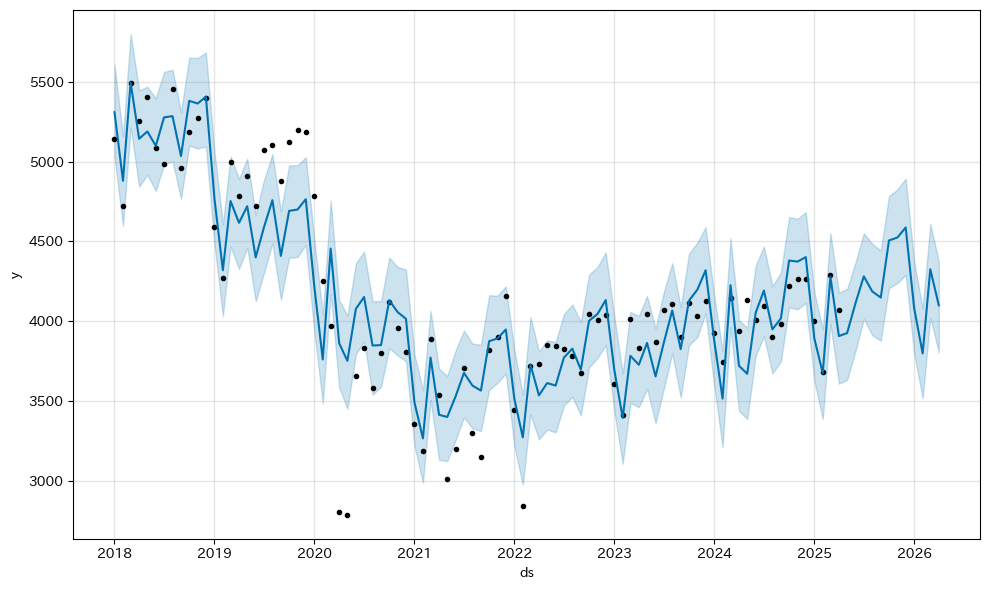

In [139]:
#グラフ上に可視化
fig_forecast = model.plot(center_weekday_forecast)

In [140]:
#予測の評価
#cutoffsとして、4つの日付を持つデータを作成
cutoffs = pd.to_datetime(['2021-1', '2022-1', '2023-1', '2024-1'])

#cross_validation関数をインポートし、実行してテストパターンを作成
#引数には、cutoffsとhorizon（うるう年を考慮して366）を指定
from prophet.diagnostics import cross_validation
center_weekday_df_cv = cross_validation(model, horizon = '366 days', cutoffs=cutoffs)

  0%|          | 0/4 [00:00<?, ?it/s]

In [141]:
#df_cvをもとに各評価指標を算出
#performance_metrics関数をインポートし、引数にdf_cvとmonthly=Trueを指定して実行
from prophet.diagnostics import performance_metrics
center_weekday_df_p = performance_metrics(center_weekday_df_cv, monthly=True)
center_weekday_df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,1,61441.576494,247.874114,205.750400,0.058937,0.060167,0.061128,0.75
1,2,228682.139389,478.207214,427.908780,0.110295,0.115194,0.118416,0.50
2,3,372691.823033,610.484908,565.182609,0.151662,0.129679,0.166742,0.00
3,4,470258.995060,685.754326,568.276761,0.143446,0.143798,0.160609,0.25
4,5,382089.806798,618.134133,448.258884,0.117008,0.082808,0.131655,0.50


<Axes: xlabel='horizon', ylabel='mape'>

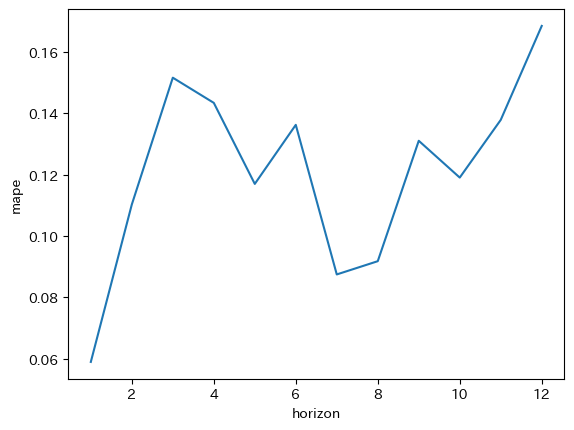

In [142]:
#mapeの推移を可視化
sns.lineplot(x='horizon', y='mape', data=center_weekday_df_p)

<Axes: xlabel='horizon', ylabel='coverage'>

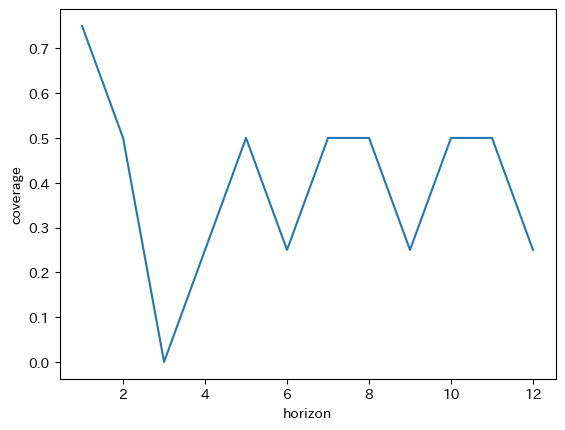

In [143]:
#不確実性区間に予測値が含まれている割合である、coverageの推移を確認
sns.lineplot(x='horizon', y='coverage', data=center_weekday_df_p)

#### `center_holiday_forecast` 休日の場合

In [144]:
# 新しいProphetモデルインスタンスを作成し、休日のデータにフィット
from prophet import Prophet
holiday_model = Prophet(seasonality_mode='multiplicative', interval_width=0.7)
holiday_model.fit(center_holiday_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [145]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
center_holiday_future = model.make_future_dataframe(periods=12, freq='MS')


In [146]:
#予測を実行
center_holiday_forecast = model.predict(center_holiday_future)

#出力された予測値や、不確実性区間を確認
center_holiday_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01,5309.489430,5001.827545,5582.006964
1,2018-02-01,4879.535917,4584.180698,5177.224320
2,2018-03-01,5494.366306,5209.027606,5760.198381
3,2018-04-01,5142.810875,4859.543455,5436.453113
4,2018-05-01,5188.523171,4911.933678,5476.391094
...,...,...,...,...
95,2025-12-01,4586.735822,4304.477305,4891.966911
96,2026-01-01,4080.882922,3766.204860,4368.873760
97,2026-02-01,3797.437081,3499.263662,4084.840820
98,2026-03-01,4324.616736,4037.947074,4626.106410


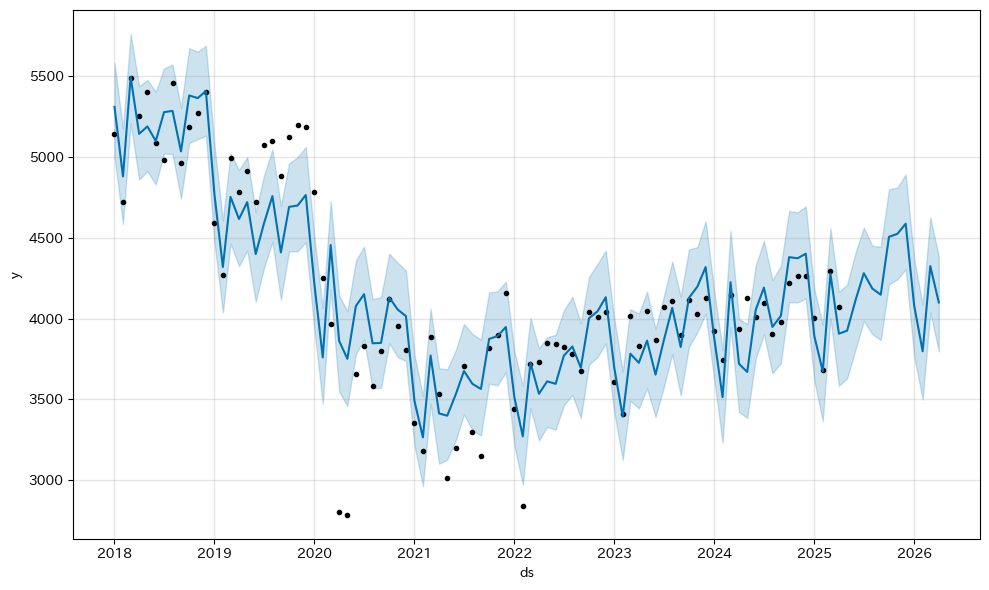

In [147]:
#グラフ上に可視化
fig_forecast = model.plot(center_holiday_forecast)

In [148]:
#予測の評価
#cutoffsとして、4つの日付を持つデータを作成
cutoffs = pd.to_datetime(['2021-1', '2022-1', '2023-1', '2024-1'])

#cross_validation関数をインポートし、実行してテストパターンを作成
#引数には、cutoffsとhorizon（うるう年を考慮して366）を指定
from prophet.diagnostics import cross_validation
center_holiday_df_cv = cross_validation(model, horizon = '366 days', cutoffs=cutoffs)

  0%|          | 0/4 [00:00<?, ?it/s]

In [149]:
#df_cvをもとに各評価指標を算出
#performance_metrics関数をインポートし、引数にdf_cvとmonthly=Trueを指定して実行
from prophet.diagnostics import performance_metrics
center_holiday_df_p = performance_metrics(center_holiday_df_cv, monthly=True)
center_holiday_df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,1,61441.576494,247.874114,205.750400,0.058937,0.060167,0.061128,0.75
1,2,228682.139389,478.207214,427.908780,0.110295,0.115194,0.118416,0.50
2,3,372691.823033,610.484908,565.182609,0.151662,0.129679,0.166742,0.00
3,4,470258.995060,685.754326,568.276761,0.143446,0.143798,0.160609,0.25
4,5,382089.806798,618.134133,448.258884,0.117008,0.082808,0.131655,0.50


<Axes: xlabel='horizon', ylabel='mape'>

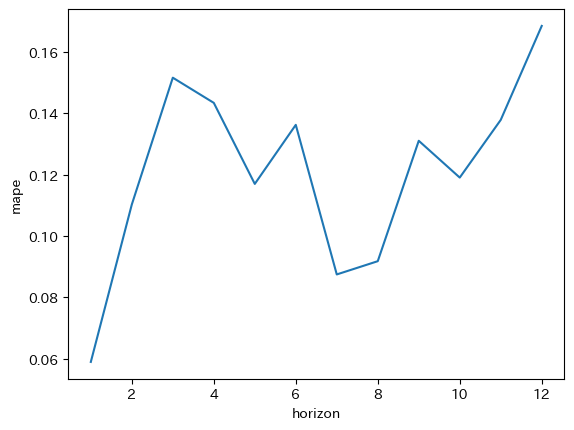

In [150]:
#mapeの推移を可視化
sns.lineplot(x='horizon', y='mape', data=center_holiday_df_p)

<Axes: xlabel='horizon', ylabel='coverage'>

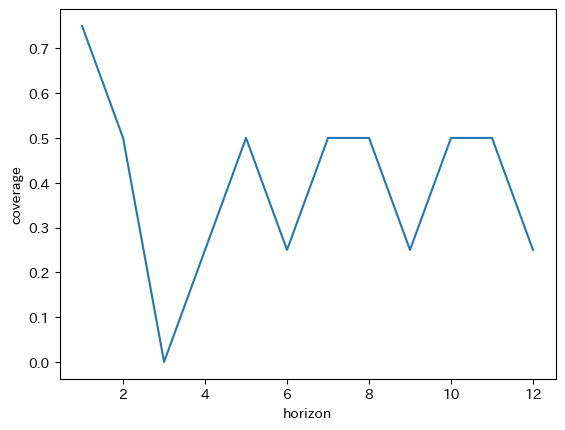

In [151]:
#不確実性区間に予測値が含まれている割合である、coverageの推移を確認
sns.lineplot(x='horizon', y='coverage', data=center_holiday_df_p)

## 考察